라이브러리 로드

In [1]:
import sionna.rt

# Other imports
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import drjit as dr
import mitsuba as mi
import os

import tensorflow as tf
import ipywidgets as widgets
from IPython.display import display, clear_output
import pandas as pd
import plotly.graph_objects as go

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
    
from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver, ITURadioMaterial,\
    Camera, PathSolver, InteractionType, RadioMapSolver, SceneObject
from sionna.rt.utils import r_hat

import importlib
import utils as ut
ut = importlib.reload(ut)

no_preview = False # Toggle to False to use the preview widget

2026-03-03 19:32:45.000397: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-03 19:32:45.013796: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772533965.028197  432857 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772533965.032746  432857 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772533965.044103  432857 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

1. Scene XML 파일 로드 및 재질 확인

In [2]:
# XML 파일 경로 보정 및 로드
xml_path = "/home/js/js/sionna-rt/src/sionna/rt/scenes/HSV/HSV_flat.xml"
scene_dir = os.path.dirname(xml_path)

scene = load_scene(xml_path, merge_shapes=False)
scene.frequency = 28e9
# 재질(Material) 정보 확인
#ut.print_scene_materials(scene)

2. 도로 재질 변경

In [3]:
red_road_mat = ITURadioMaterial(name="red_road_mat_main",
                                itu_type="concrete",
                                thickness=0.2,
                                color=[0.6, 0.15, 0.18])
scene.add(red_road_mat)

road_object_id = "elm__19"

if road_object_id in scene.objects:
    scene.objects[road_object_id].radio_material = red_road_mat
    print(f"[설정] 도로({road_object_id})를 빨간색으로 변경했습니다.")

[설정] 도로(elm__19)를 빨간색으로 변경했습니다.


In [4]:
green_mountain_mat = ITURadioMaterial(name="green_mountain_mat",
                                itu_type="wood",
                                thickness=0.2,
                                color=[0.18, 0.32, 0.12])
scene.add(green_mountain_mat)

mountain_object_id = ["map_2_osm_forest-itu_wood", "map_2_osm_forest-itu_wood-001", "map_2_osm_forest-itu_wood-002"]
for i in mountain_object_id:
    if i in scene.objects:
        scene.objects[i].radio_material = green_mountain_mat
        print(f"[설정] ({i})를 초록색으로 변경했습니다.")

[설정] (map_2_osm_forest-itu_wood)를 초록색으로 변경했습니다.
[설정] (map_2_osm_forest-itu_wood-001)를 초록색으로 변경했습니다.
[설정] (map_2_osm_forest-itu_wood-002)를 초록색으로 변경했습니다.


3. 도로 정점 추출

In [5]:
road_positions = ut.get_road_positions_from_object(
    scene,
    road_object_id,
    dtype=np.float16,       # 한글 주석: 연산용 기본 타입
    round_decimals=3,       # 한글 주석: 화면 표시 자릿수만 줄임
)

if len(road_positions) == 0:
    print("[안내] 추출된 좌표가 없습니다.")
else:
    print("dtype:", road_positions.dtype)
    print("first road position:", road_positions[0])

[탐색] Mitsuba Scene 내부에서 'elm__19' 형상을 찾습니다...
  -> 추출된 도로 좌표 수: 24개 (dtype=float16)
dtype: float16
first road position: [ -3.057 406.      0.725]


4. 초기 위치 테스트

In [6]:
# 설정 및 초기화
target_pos = np.array(road_positions[0], dtype=np.float32)
print("="*60 + f"\n[설정] 테스트 목표: {target_pos}\n" + "="*60)

# 장치 배치
scene.tx_array = PlanarArray(num_rows=1, num_cols=1, pattern="iso", polarization="VH")
scene.rx_array = PlanarArray(num_rows=1, num_cols=1, pattern="iso", polarization="VH")

tx_positions = [[0, -264, 11]]
tx_names = ["Tx_1"]

# 기존 객체 제거
for name in tx_names + ["Car_Marker"]:
    if name in scene.transmitters:
        scene.remove(name)
if "rx_car" in scene.receivers:
    scene.remove("rx_car")
if "rx_vehicle" in scene.objects:
    scene.edit(remove="rx_vehicle")

# Tx 배치
for i, pos in enumerate(tx_positions):
    tx = Transmitter(name=tx_names[i], position=pos, power_dbm=43)
    tx.transmit_antenna = scene.tx_array
    tx.look_at(target_pos)
    scene.add(tx)
    print(f" -> {tx_names[i]} 배치 완료.")

[설정] 테스트 목표: [ -3.0566406  406.           0.72509766]
 -> Tx_1 배치 완료.


In [7]:
# 자동차 Mesh 생성
car_material = ITURadioMaterial(
    name="car_material_rt",
    itu_type="metal",
    thickness=0.01,
    color=(0,1,1),
)
scene.add(car_material)

vehicle = SceneObject(
    fname=sionna.rt.scene.low_poly_car,
    name="rx_vehicle",
    radio_material=car_material,
)
scene.edit(add=[vehicle])

# rx 추가
rx = Receiver(
    name="rx_car",
    position=np.array([target_pos[0], target_pos[1], 3.0], dtype=np.float32)
)

rx.receive_antenna = scene.rx_array
scene.add(rx)
print(" -> 자동차(Rx) 및 Mesh 배치 완료.")

 -> 자동차(Rx) 및 Mesh 배치 완료.


In [8]:
vehicle.scaling = mi.Vector3f(1, 1, 1)
vehicle.position = mi.Vector3f(float(target_pos[0]), float(target_pos[1]), 1.3)
vehicle.orientation = mi.Point3f(np.pi/2, 0.0, 0.0)

# 시뮬레이션
print("[연산] 경로 계산 시작...")
solver = PathSolver()
paths = solver(scene, max_depth=5, samples_per_src=1000000, diffuse_reflection=True, diffraction=True)

# 시각화
cam = Camera(position=target_pos + np.array([0, 100, 100]), look_at=target_pos)
print("[시각화] 3D 뷰어 실행")
scene.preview(paths=paths, show_devices=True)

[연산] 경로 계산 시작...
[시각화] 3D 뷰어 실행


***메인 시뮬레이션***

경로 준비

In [9]:
# 한글 주석: 먼저 XY에서 정점 인덱스 분포를 확인
ut.plot_vertices_index(
    road_positions,
    width=1000,
    height=800,
    marker_size=5,
)

In [10]:
# 한글 주석: 위 Cell 에서 본 인덱스를 직접 입력
if 'road_positions' not in globals():
    raise ValueError("❌ 'road_positions' 데이터가 없습니다.")

path_indices = [4,16]

path_data = ut.prepare_vehicle_path(
    road_positions=road_positions,
    path_indices=path_indices,
    z_offset=2.7,
    speed_ms=100.0 / 3.6,
    delta_t=0.5,
)

waypoints = path_data["waypoints"]
time_steps = path_data["time_steps"]
print("waypoints:", waypoints.shape, "| time_steps:", len(time_steps))
print(f"총 이동 거리: {path_data['total_distance']:.2f} m")
print(f"총 소요 시간: {path_data['total_time']:.2f} s")

waypoints: (2, 3) | time_steps: 31
총 이동 거리: 403.02 m
총 소요 시간: 14.51 s


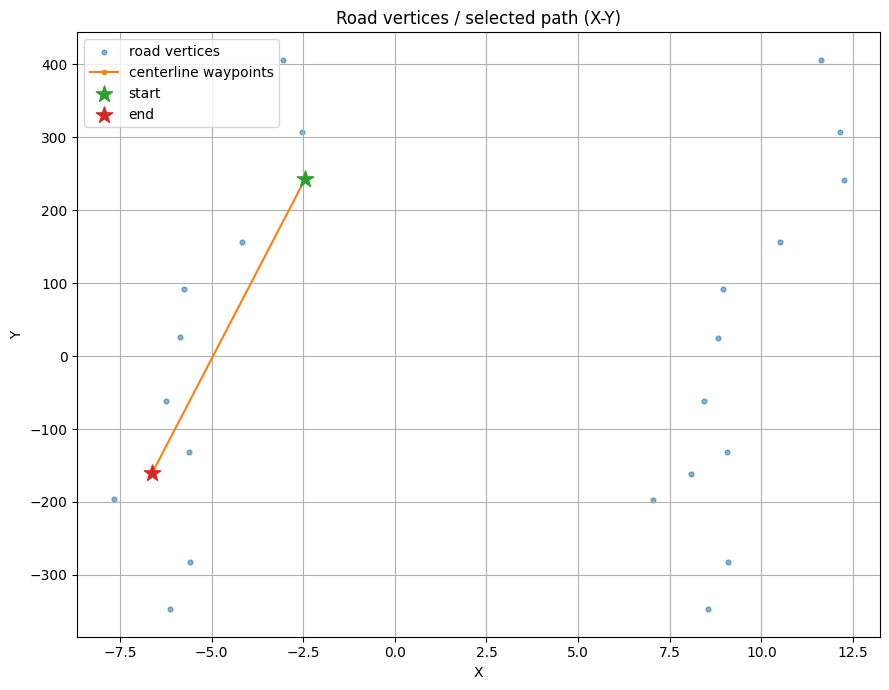

In [11]:
ut.plot_vertices_xy(
    road_positions=road_positions,
    waypoints=waypoints,
    start_point=path_indices[0],
    end_point=path_indices[-1],
    figsize=(9, 7),
)

Scene 초기화 (Tx/Rx + Solver)

In [12]:
tx_names, rx, solver, vehicle = ut.setup_scene_for_vehicle_path(
    scene=scene,
    path_data=path_data,
    tx_positions=tx_positions,
    tx_names=tx_names,
    tx_power_dbm=43.0,
    display_radius=2.0,
    add_vehicle=True,
    vehicle_name="rx_vehicle",
    vehicle_scale=(2.5, 2.5, 2.5),
    vehicle_z=0.3,
    rx_z=3.0,
)

start_pos, start_vel = ut.get_state_at_time(path_data, 0.0)
print("초기 위치:", np.round(start_pos, 3))
print("초기 속도:", np.round(start_vel, 3))

초기 위치: [ -2.451 242.25    3.318]
초기 속도: [-2.8800e-01 -2.7776e+01 -1.2000e-02]


Interactive 위젯 실행

In [13]:
# path_loss.ipynb - Interactive 위젯 셀(기존 cell 18) 교체 예시
slider, output_widget = ut.create_vehicle_simulation_widgets(
    scene=scene,
    path_data=path_data,
    tx_names=tx_names,
    rx=rx,
    solver=solver,
    vehicle=vehicle,
    vehicle_z=1.3,
    rx_z=4.0,
    max_depth=3,
    max_num_paths_per_src=100000,
    samples_per_src=100000,
    diffuse_reflection=True,
    diffraction=True,
    synthetic_array=True,
    resolution=(800, 600),
)
print("▼ 슬라이더를 움직여보세요.")
display(slider, output_widget)

▼ 슬라이더를 움직여보세요.


IntSlider(value=0, description='Time Step:', layout=Layout(width='600px'), max=30)

Output()

CIR 시각화

In [14]:
# path_loss.ipynb에서 사용 예시
cir_widget = ut.create_cir_slider_widget(
    scene=scene,
    rx=rx,
    solver=solver,
    path_data=path_data,
    tx_names=tx_names,
    max_depth=3,
    samples_per_src=100000,
    diffuse_reflection=True,
    diffraction=True,
    synthetic_array=True,
    figsize=(8, 4),
    continuous_update=False,  # True로 바꾸면 드래그 중에도 연속 갱신
)
display(cir_widget)

CFR 시각화

In [15]:
# path_loss.ipynb 사용 예시 2: 주파수 스윕
freqs_sweep = np.linspace(27.5e9, 28.5e9, 801, dtype=np.float32)

cfr_widget_sweep = ut.create_cfr_slider_widget(
    scene=scene,
    rx=rx,
    solver=solver,
    path_data=path_data,
    tx_names=tx_names,
    frequencies=freqs_sweep,
    normalize=True,
    normalize_delays=True,
    max_depth=3,
    samples_per_src=100000,
    diffuse_reflection=True,
    diffraction=True,
    synthetic_array=True,
    continuous_update=False
)
display(cfr_widget_sweep)


TAP 시각화

In [16]:
# 한글 주석: taps 설정값
bandwidth = 500e6          # 채널 대역폭 [Hz]
l_min, l_max = 100, 300     # 탭 인덱스 범위
sampling_frequency = 10e4         # 시간축 샘플링 주파수 [Hz]
num_time_steps = 16       # 시간 샘플 수(도플러 반영)

In [17]:
# 함수 한번만 호출하면 관련된 UI와 위젯 이벤트가 예쁘게 반환됩니다.
widget_view = ut.create_taps_pdp_widgets(
    scene=scene, 
    rx=rx, 
    solver=solver, 
    path_data=path_data, 
    tx_names=tx_names,
    bandwidth=bandwidth,           # 예: 100e6
    l_min=l_min,                   # 예: -10
    l_max=l_max,                   # 예: 50
    sampling_frequency=sampling_frequency,  # 예: 1e9
    num_time_steps=num_time_steps  # 예: 1
)

# 최종적으로 화면에 표시
display(widget_view)

영상 저장

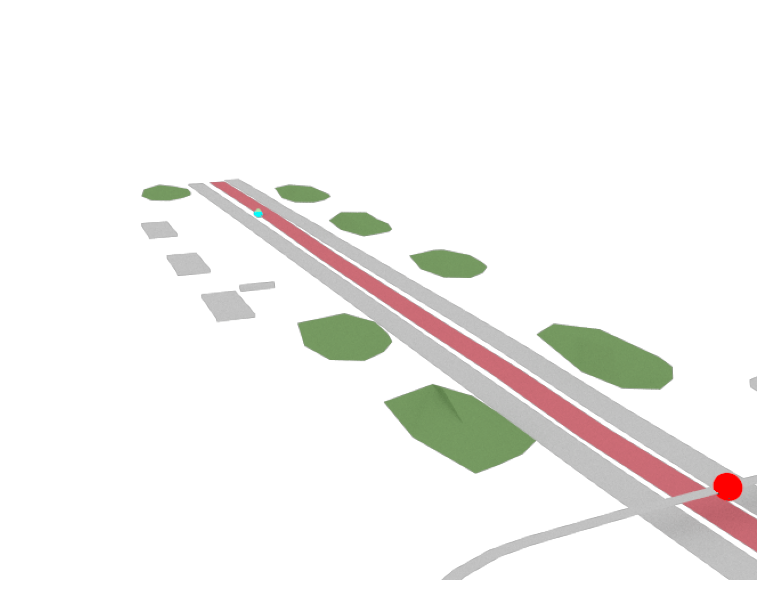

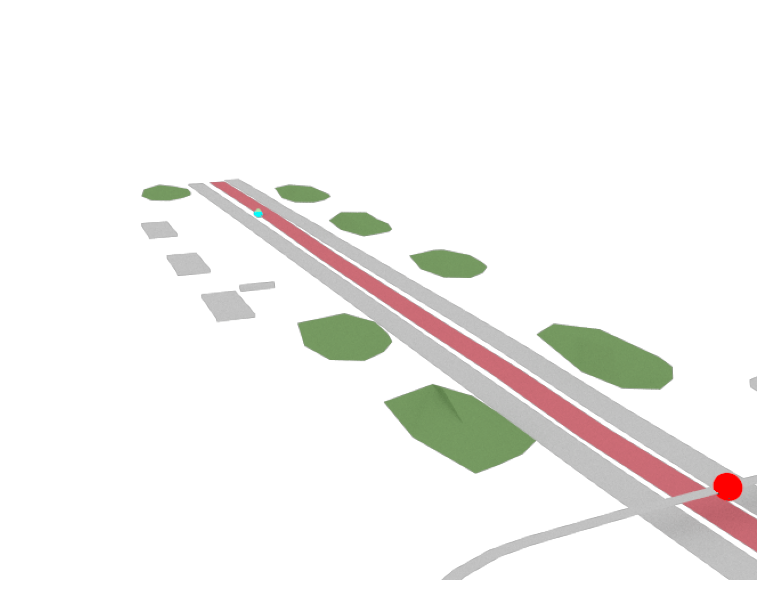

In [18]:
# 구도 확인
cam = Camera(position=[-200, -450, 150], look_at=[0, 0, 0])
scene.render(camera=cam)

In [19]:
# path_loss.ipynb - 영상 저장 셀(기존 cell 31) 교체 예시
ut.export_simulation_video(
    scene=scene,
    rx=rx,
    solver=solver,
    path_data=path_data,
    tx_names=tx_names,
    camera=cam,
    vehicle=vehicle,
    vehicle_z=0.3,
    rx_z=3.0,
    filename="HSV.mp4",
    fps=10,
    resolution=(800, 600),
    save_frames_dir="simulation_frames"
)

🎥 애니메이션 렌더링 시작... (총 31 프레임)
저장 경로: HSV.mp4


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (800, 600) to (800, 608) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


  -> 프레임 렌더링 완료: 1/31 (3.2%)
  -> 프레임 렌더링 완료: 2/31 (6.5%)
  -> 프레임 렌더링 완료: 3/31 (9.7%)
  -> 프레임 렌더링 완료: 4/31 (12.9%)
  -> 프레임 렌더링 완료: 5/31 (16.1%)
  -> 프레임 렌더링 완료: 6/31 (19.4%)
  -> 프레임 렌더링 완료: 7/31 (22.6%)
  -> 프레임 렌더링 완료: 8/31 (25.8%)
  -> 프레임 렌더링 완료: 9/31 (29.0%)
  -> 프레임 렌더링 완료: 10/31 (32.3%)
  -> 프레임 렌더링 완료: 11/31 (35.5%)
  -> 프레임 렌더링 완료: 12/31 (38.7%)
  -> 프레임 렌더링 완료: 13/31 (41.9%)
  -> 프레임 렌더링 완료: 14/31 (45.2%)
  -> 프레임 렌더링 완료: 15/31 (48.4%)
  -> 프레임 렌더링 완료: 16/31 (51.6%)
  -> 프레임 렌더링 완료: 17/31 (54.8%)
  -> 프레임 렌더링 완료: 18/31 (58.1%)
  -> 프레임 렌더링 완료: 19/31 (61.3%)
  -> 프레임 렌더링 완료: 20/31 (64.5%)
  -> 프레임 렌더링 완료: 21/31 (67.7%)
  -> 프레임 렌더링 완료: 22/31 (71.0%)
  -> 프레임 렌더링 완료: 23/31 (74.2%)
  -> 프레임 렌더링 완료: 24/31 (77.4%)
  -> 프레임 렌더링 완료: 25/31 (80.6%)
  -> 프레임 렌더링 완료: 26/31 (83.9%)
  -> 프레임 렌더링 완료: 27/31 (87.1%)
  -> 프레임 렌더링 완료: 28/31 (90.3%)
  -> 프레임 렌더링 완료: 29/31 (93.5%)
  -> 프레임 렌더링 완료: 30/31 (96.8%)
  -> 프레임 렌더링 완료: 31/31 (100.0%)
🎬 렌더링 완료! 'HSV.mp4' 파일이 생성되었습니다.
